In [ ]:

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

In [2]:

iris_dataset = load_iris()


iris_df = pd.DataFrame(
    data=iris_dataset.data,
    columns=iris_dataset.feature_names
)


iris_df['species'] = iris_dataset.target


species_mapping = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
iris_df['species_name'] = iris_df['species'].map(species_mapping)

print("Dataset Shape:", iris_df.shape)
print("\nFirst 5 rows:")
print(iris_df.head())
print("\nDataset Information:")
print(iris_df.info())

Dataset Shape: (150, 6)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       Setosa  
1        0       Setosa  
2        0       Setosa  
3        0       Setosa  
4        0       Setosa  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal l

In [3]:

print("Statistical Summary of Features:\n")
print(iris_df.describe())


print("\nMissing Values:")
print(iris_df.isnull().sum())


print("\nSpecies Distribution:")
print(iris_df['species_name'].value_counts())

Statistical Summary of Features:

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Missing Values:
sepal length (cm)    

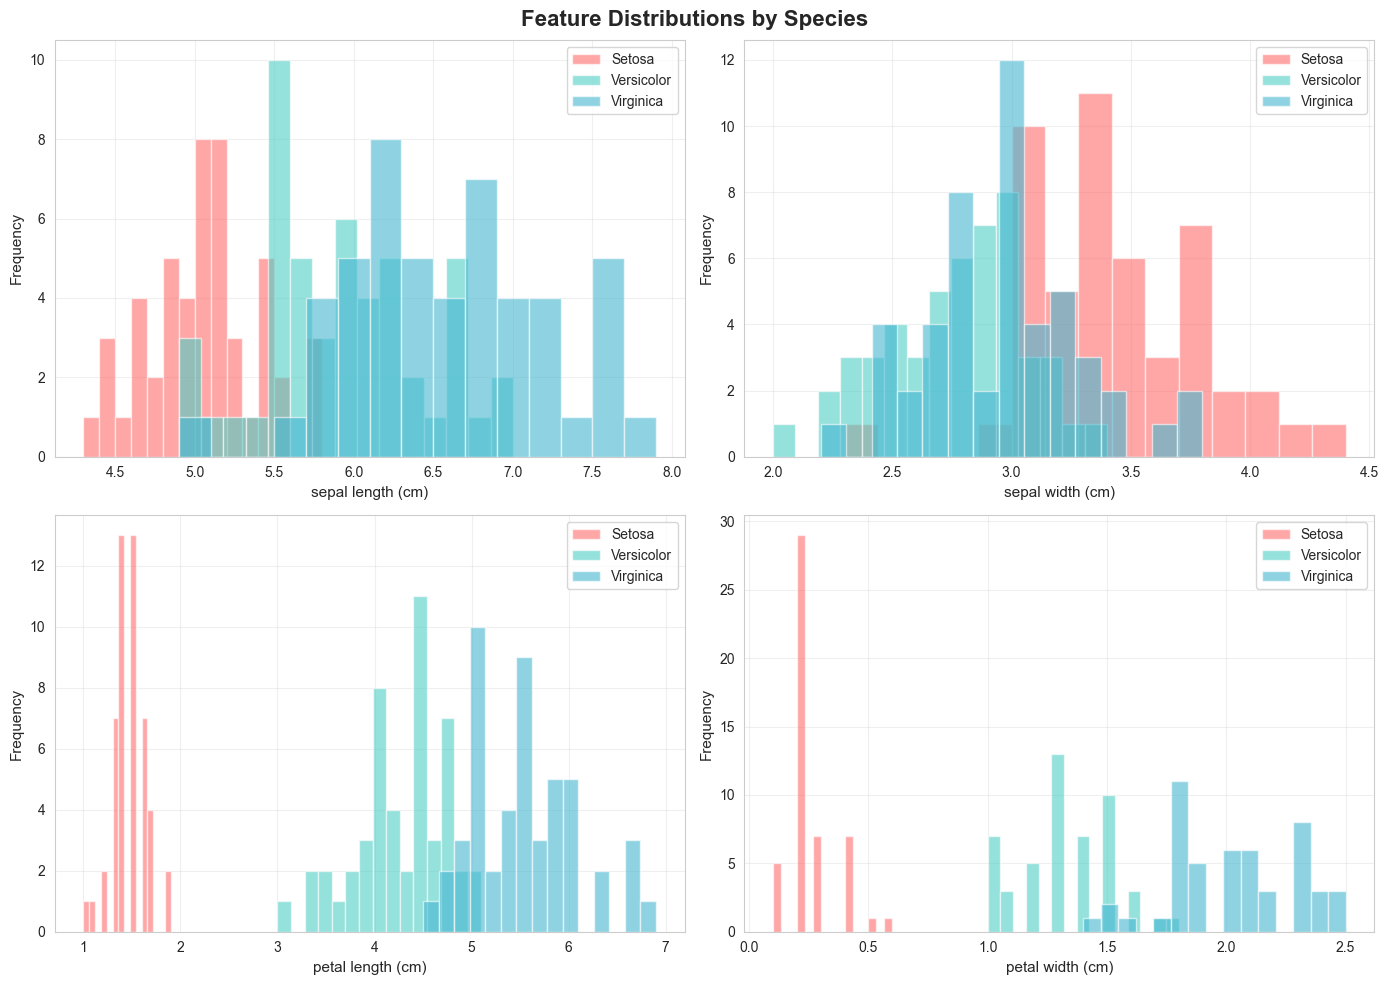

In [4]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by Species', fontsize=16, fontweight='bold')

features = iris_df.columns[:4]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, feature in enumerate(features):
    row, col = idx // 2, idx % 2
    for species_id, species_name in species_mapping.items():
        data = iris_df[iris_df['species'] == species_id][feature]
        axes[row, col].hist(data, alpha=0.6, label=species_name, bins=15, color=colors[species_id])
    
    axes[row, col].set_xlabel(feature, fontsize=11)
    axes[row, col].set_ylabel('Frequency', fontsize=11)
    axes[row, col].legend()
    axes[row, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

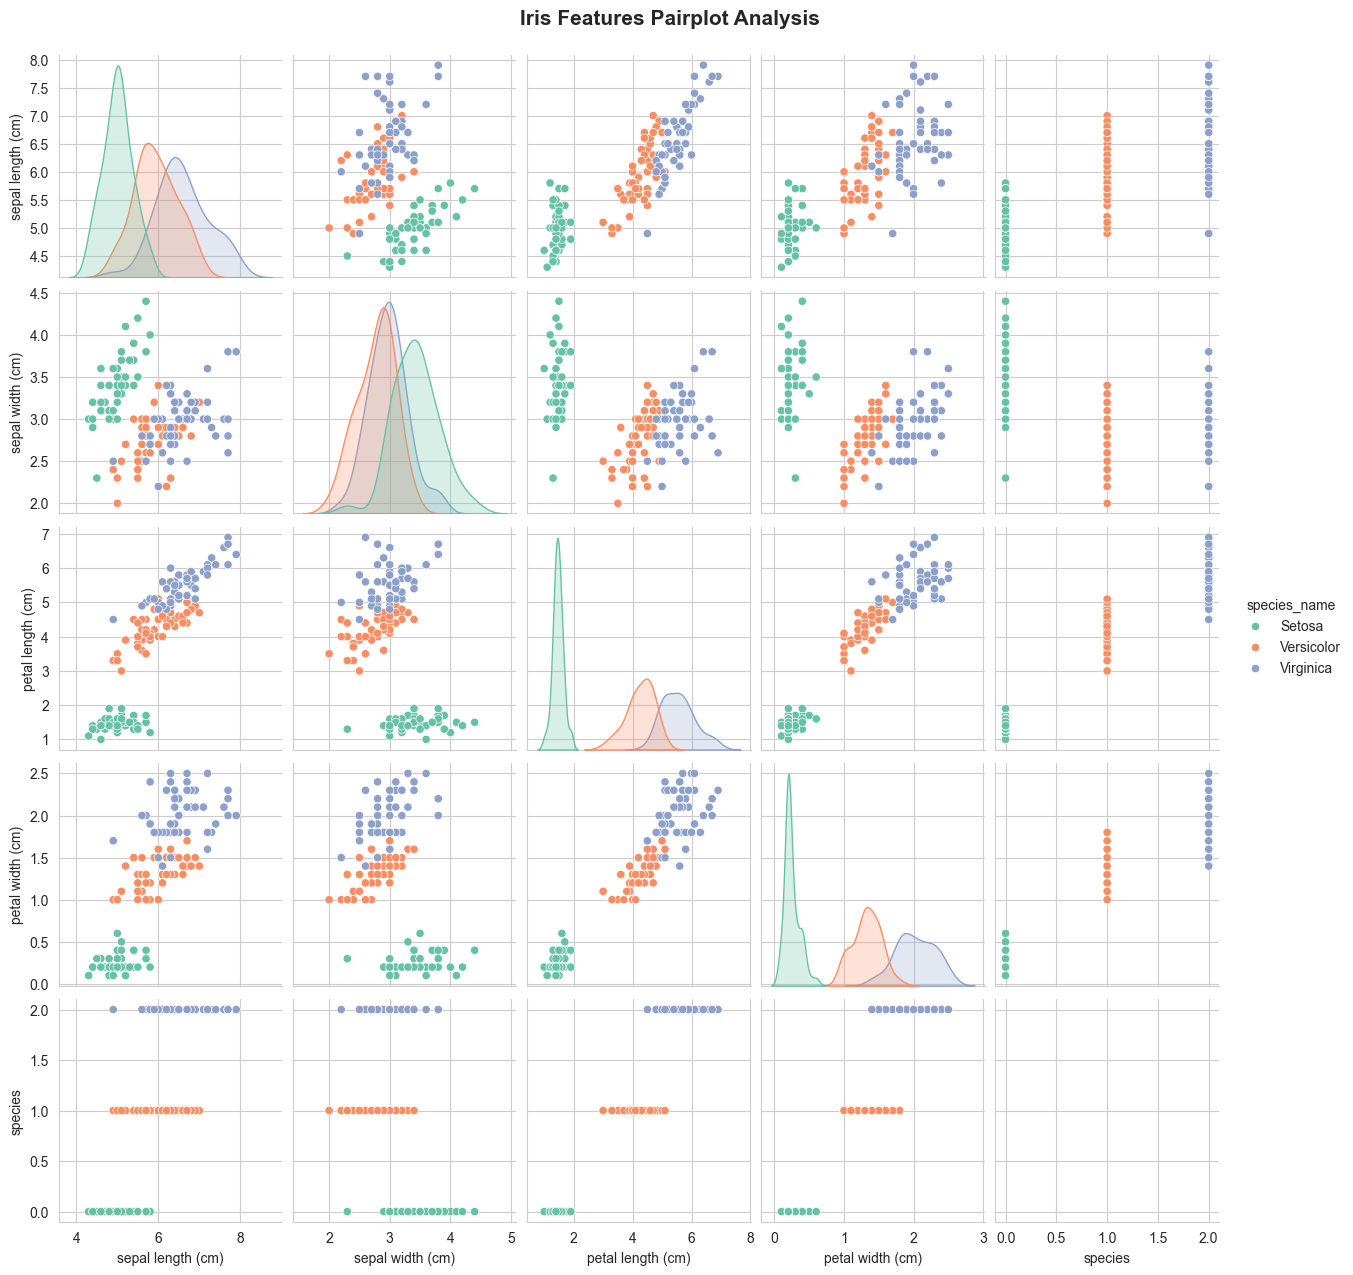

In [5]:
pairplot_fig = sns.pairplot(
    iris_df, 
    hue='species_name', 
    palette='Set2',
    diag_kind='kde',
    height=2.5
)
pairplot_fig.fig.suptitle('Iris Features Pairplot Analysis', y=1.02, fontsize=15, fontweight='bold')
plt.show()

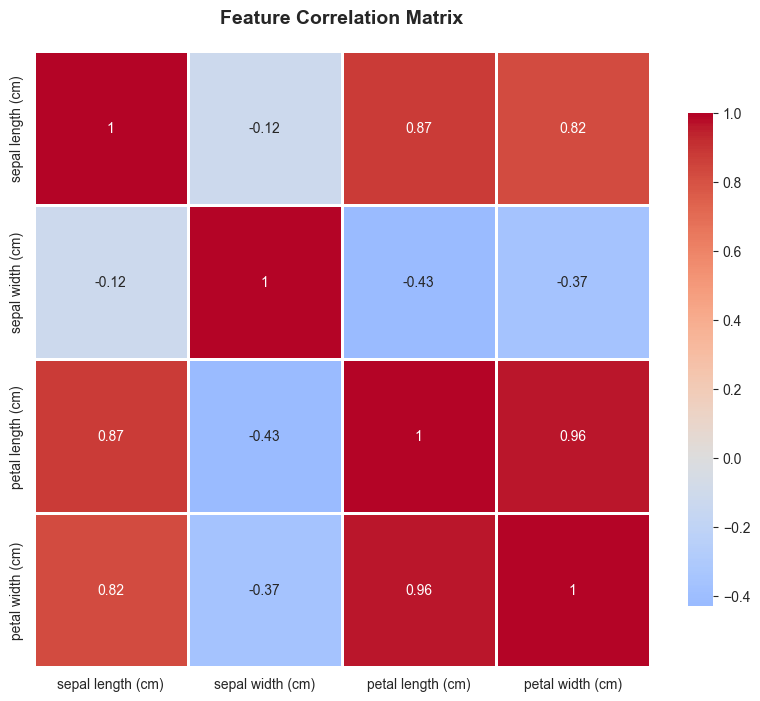

In [6]:
correlation_matrix = iris_df.iloc[:, :4].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.show()


In [7]:
X = iris_df.iloc[:, :4].values
y = iris_df['species'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y  
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nFeature shape: {X_train.shape}")


Training set size: 105 samples
Testing set size: 45 samples

Feature shape: (105, 4)


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been standardized!")
print(f"Mean of scaled training data: {X_train_scaled.mean():.4f}")
print(f"Standard deviation of scaled training data: {X_train_scaled.std():.4f}")

Features have been standardized!
Mean of scaled training data: 0.0000
Standard deviation of scaled training data: 1.0000


In [11]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42)
}

results = {}

for model_name, model in models.items():
   
   model.fit(X_train_scaled, y_train)
    
   y_pred = model.predict(X_test_scaled)
    
   accuracy = accuracy_score(y_test, y_pred)
   results[model_name] = accuracy
    
   print(f"\n{'='*50}")
   print(f"{model_name}")
   print(f"{'='*50}")
   print(f"Accuracy: {accuracy*100:.2f}%")


Random Forest
Accuracy: 88.89%

K-Nearest Neighbors
Accuracy: 91.11%

Support Vector Machine
Accuracy: 93.33%


In [12]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"Accuracy: {results[best_model_name]*100:.2f}%\n")

y_pred_best = best_model.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=species_mapping.values()))


🏆 Best Model: Support Vector Machine
Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        15
  Versicolor       0.88      0.93      0.90        15
   Virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



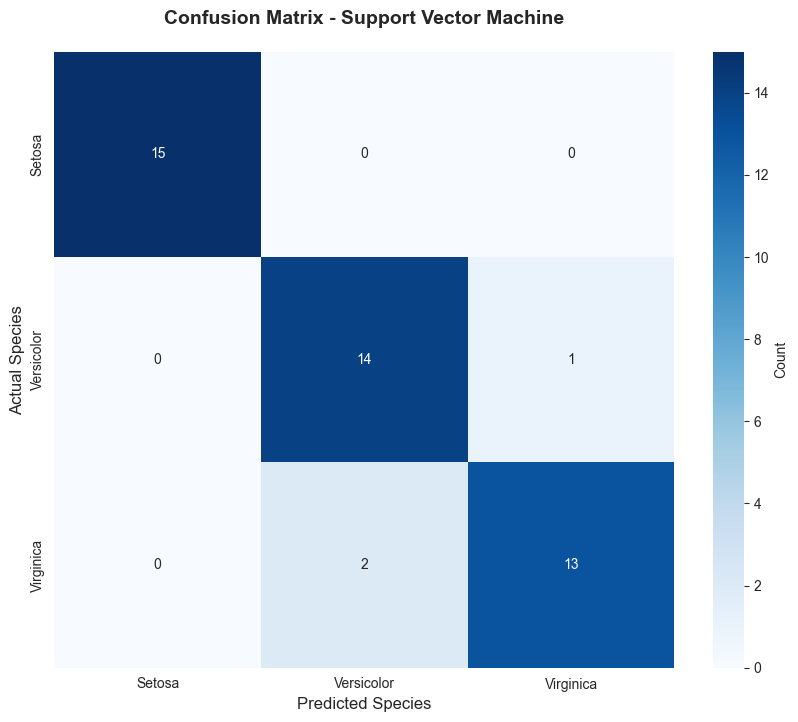

In [13]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=species_mapping.values(),
    yticklabels=species_mapping.values(),
    cbar_kws={'label': 'Count'}
)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('Actual Species', fontsize=12)
plt.show()

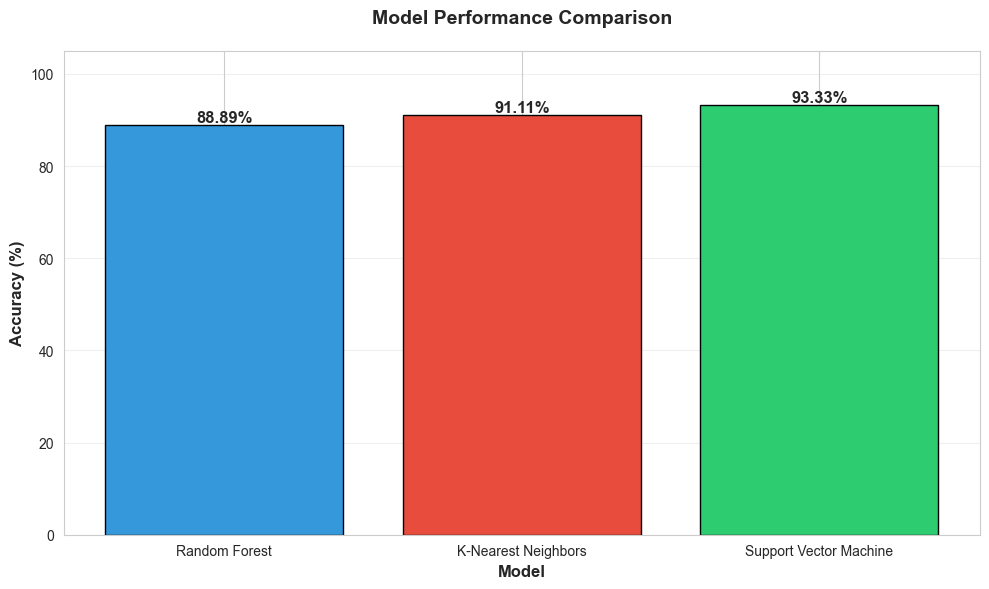

In [14]:
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [results[name]*100 for name in model_names]

bars = plt.bar(model_names, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold', pad=20)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
new_flower_data = np.array([
    [5.1, 3.5, 1.4, 0.2],  # Likely Setosa
    [6.2, 2.9, 4.3, 1.3],  # Likely Versicolor
    [7.3, 3.0, 6.3, 1.8]   # Likely Virginica
])

new_flower_scaled = scaler.transform(new_flower_data)

predictions = best_model.predict(new_flower_scaled)

print("Predictions for New Flower Samples:\n")
for idx, pred in enumerate(predictions):
    print(f"Sample {idx+1}: {new_flower_data[idx]}")
    print(f"Predicted Species: {species_mapping[pred]}\n")

Predictions for New Flower Samples:

Sample 1: [5.1 3.5 1.4 0.2]
Predicted Species: Setosa

Sample 2: [6.2 2.9 4.3 1.3]
Predicted Species: Versicolor

Sample 3: [7.3 3.  6.3 1.8]
Predicted Species: Virginica

